# Trabajo Final: Aprendizaje Supervisado y modelos binarios

- Sebastian Chavarry

# Objetivo general

- Construir un modelo predictivo para determinar si un cliente realizara churn o no

# Objetivos especificos

- Analizar el comportamiento de los clientes mediante técnicas de exploración de datos.
- Preprocesar la información para adecuarla a los algoritmos de Machine Learning.
- Implementar y comparar modelos de clasificación (Regresión, Árboles, Ensembles, Redes Neuronales).
- Evaluar el rendimiento utilizando métricas robustas.
- Seleccionar el mejor modelo para la toma de decisiones de negocio.

# Fase 0: Preparación del Entorno y Datos

In [1]:
# Cargar librerias necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion de visualizacion

sns.set(style='whitegrid')
%matplotlib inline

In [2]:
# Cargar dataset

df = pd.read_csv('05 Churn_Banco.csv', sep=';')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Card_Category,Months_on_book,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,3,High School,$60K - $80K,Blue,39,1,12691.0,1144,42,0.061
1,818770008,Existing Customer,49,5,Graduate,Less than $40K,Blue,44,1,8256.0,1291,33,0.105
2,713982108,Existing Customer,51,3,Graduate,$80K - $120K,Blue,36,1,3418.0,1887,20,0.000
3,769911858,Existing Customer,40,4,High School,Less than $40K,Blue,34,4,3313.0,1171,20,0.760
4,709106358,Existing Customer,40,3,Uneducated,$60K - $80K,Blue,21,1,4716.0,816,28,0.000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLIENTNUM               10127 non-null  int64  
 1   Attrition_Flag          10127 non-null  str    
 2   Customer_Age            10127 non-null  int64  
 3   Dependent_count         10127 non-null  int64  
 4   Education_Level         10127 non-null  str    
 5   Income_Category         10127 non-null  str    
 6   Card_Category           10127 non-null  str    
 7   Months_on_book          10127 non-null  int64  
 8   Months_Inactive_12_mon  10127 non-null  int64  
 9   Credit_Limit            10127 non-null  float64
 10  Total_Trans_Amt         10127 non-null  int64  
 11  Total_Trans_Ct          10127 non-null  int64  
 12  Avg_Utilization_Ratio   10127 non-null  float64
dtypes: float64(2), int64(7), str(4)
memory usage: 1.0 MB


## Contexto del dataset

- No hay nulls en el dataset para ninguna variable
- 7 variables numericas
- 4 variables categoricas

## Variables criticas

Attrition_Flag --> Variable Objetivo

Variables de comportamiento:
- Months_Inactive_12_mon: Meses inactivos en el último año - probablemente el predictor más fuerte
- Total_Trans_Ct y Total_Trans_Amt: Volumen y cantidad de transacciones - clientes churned probablemente tienen menos actividad
Avg_Utilization_Ratio: Qué tanto usan su límite de crédito

Variables demograficas: 
- Customer_Age, Dependent_count: Segmentación demográfica
- Months_on_book: Antigüedad del cliente (clientes nuevos podrían tener mayor churn)
- Education_Level, Income_Category: Nivel socioeconómico

Variables de producto:
- Card_Category: Tipo de tarjeta (Blue, Gold, etc.) - podría correlacionar con retention
- Credit_Limit: Límite de crédito otorgado

In [4]:
# Reporte completo de duplicados
print("=== ANÁLISIS DE DUPLICADOS ===")
print(f"\nTotal de registros: {len(df)}")
print(f"Filas completamente duplicadas: {df.duplicated().sum()}")
print(f"CLIENTNUMs duplicados: {df.duplicated(subset=['CLIENTNUM']).sum()}")
print(f"CLIENTNUMs únicos: {df['CLIENTNUM'].nunique()}")

# Si encuentras duplicados, ver ejemplos
if df.duplicated(subset=['CLIENTNUM']).sum() > 0:
    print("\nEjemplos de CLIENTNUMs duplicados:")
    print(df[df.duplicated(subset=['CLIENTNUM'], keep=False)].head(10))

=== ANÁLISIS DE DUPLICADOS ===

Total de registros: 10127
Filas completamente duplicadas: 0
CLIENTNUMs duplicados: 0
CLIENTNUMs únicos: 10127


> No hay valores nulos ni duplicados

### Convertimos las variables categoricas a variables numericas

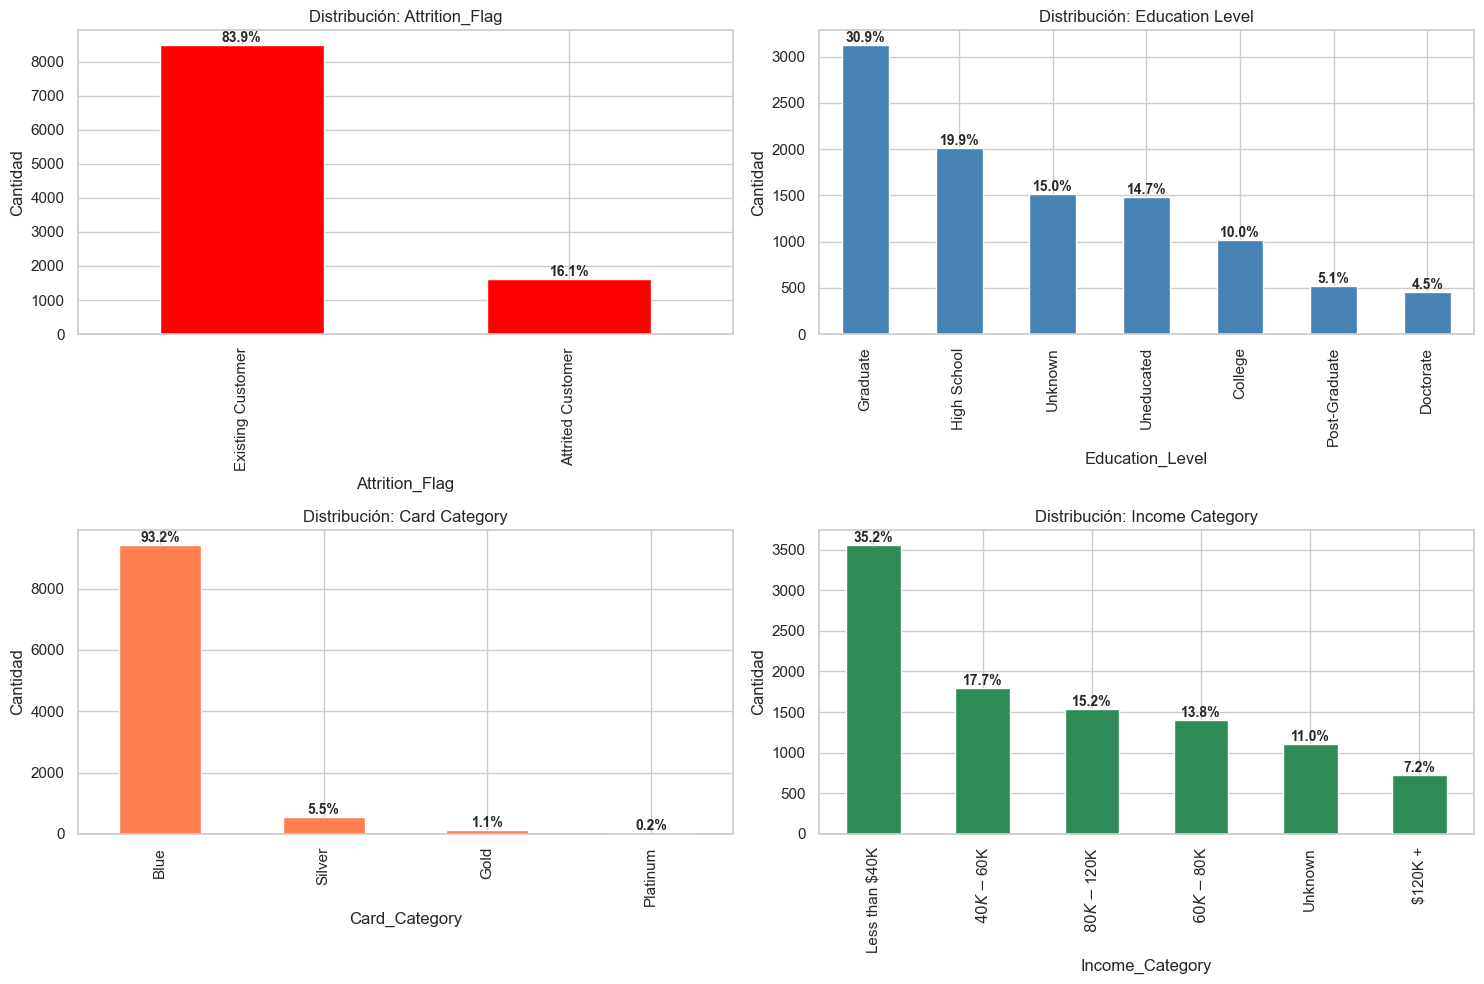

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Función helper para agregar porcentajes
def add_percentages(ax, data):
    total = data.sum()
    for i, (value, count) in enumerate(data.items()):
        percentage = (count / total) * 100
        ax.text(i, count, f'{percentage:.1f}%', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Attrition Flag
attrition_counts = df['Attrition_Flag'].value_counts()
attrition_counts.plot(kind='bar', ax=axes[0, 0], color='red')
axes[0, 0].set_title('Distribución: Attrition_Flag')
axes[0, 0].set_ylabel('Cantidad')
add_percentages(axes[0, 0], attrition_counts)

# Education Level
education_counts = df['Education_Level'].value_counts()
education_counts.plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Distribución: Education Level')
axes[0, 1].set_ylabel('Cantidad')
add_percentages(axes[0, 1], education_counts)

# Card Category
card_counts = df['Card_Category'].value_counts()
card_counts.plot(kind='bar', ax=axes[1, 0], color='coral')
axes[1, 0].set_title('Distribución: Card Category')
axes[1, 0].set_ylabel('Cantidad')
add_percentages(axes[1, 0], card_counts)

# Income Category
income_counts = df['Income_Category'].value_counts()
income_counts.plot(kind='bar', ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('Distribución: Income Category')
axes[1, 1].set_ylabel('Cantidad')
add_percentages(axes[1, 1], income_counts)

plt.tight_layout()
plt.show()

### Decisiones:
#### Attrition_Flag (Target)

- Desbalance 83.9% vs 16.1% (ratio 5.2:1)
- Requiere class_weight='balanced' o SMOTE si baseline falla

#### Card_Category (critico):

- Blue domina con 93.2% - casi todos los clientes
- Gold (1.1%) y Platinum (0.2%) tienen <150 ejemplos combinados
- Acción requerida: Agrupar Gold+Platinum en "Premium" antes de one-hot encoding

#### Education_Level:

- Distribución balanceada - Graduate (30.9%), High School (19.9%)
- Todas las categorías >4% - representación suficiente
- Acción: Ordinal encoding directo, sin cambios

#### Income_Category:
 
- Distribución razonable - Less than $40K (35.2%) es mayoría
- Unknown (11.0%) necesita manejo
- Orden claro de ingresos sugiere ordinal encoding
- Acción: Imputar Unknown con moda + ordinal encoding (1-5)

In [6]:
# En el caso de la variable Target

from sklearn.preprocessing import LabelEncoder

# Solo 2 valores: "Existing Customer" vs "Attrited Customer"
le = LabelEncoder()
df['Attrition_Flag'] = le.fit_transform(df['Attrition_Flag'])
# 0 = Existing, 1 = Attrited

## TODO: En caso el baseline afecte los resultados aplicar SMOTE

In [7]:
# CÓDIGO FINAL RECOMENDADO

# 1. Analizar si Unknown es informativo
print("=== ANÁLISIS DE UNKNOWN ===")
print(f"Porcentaje Unknown: {(df['Education_Level'] == 'Unknown').mean() * 100:.1f}%")

# Churn rate de Unknown vs resto
unknown_churn = df[df['Education_Level'] == 'Unknown']['Attrition_Flag'].apply(
    lambda x: 1 if x == 'Attrited Customer' else 0
).mean()
known_churn = df[df['Education_Level'] != 'Unknown']['Attrition_Flag'].apply(
    lambda x: 1 if x == 'Attrited Customer' else 0
).mean()

print(f"Churn rate Unknown: {unknown_churn * 100:.1f}%")
print(f"Churn rate Known: {known_churn * 100:.1f}%")
print(f"Diferencia: {abs(unknown_churn - known_churn) * 100:.1f} puntos porcentuales")

# 2. Decisión basada en datos
if abs(unknown_churn - known_churn) > 0.05:  # >5% diferencia
    print("\n→ Unknown ES predictivo. Crear flag + imputar")
    df['Education_Unknown'] = (df['Education_Level'] == 'Unknown').astype(int)
    mode_education = df[df['Education_Level'] != 'Unknown']['Education_Level'].mode()[0]
    df['Education_Level'] = df['Education_Level'].replace('Unknown', mode_education)
else:
    print("\n→ Unknown NO es predictivo. Solo imputar con moda")
    mode_education = df[df['Education_Level'] != 'Unknown']['Education_Level'].mode()[0]
    df['Education_Level'] = df['Education_Level'].replace('Unknown', mode_education)

# 3. Ordinal encoding
education_mapping = {
    'Uneducated': 0,
    'High School': 1,
    'College': 2,
    'Graduate': 3,
    'Post-Graduate': 4,
    'Doctorate': 5
}
df['Education_Level_Encoded'] = df['Education_Level'].map(education_mapping)

print("\n=== ENCODING FINAL ===")
print(df[['Education_Level', 'Education_Level_Encoded']].drop_duplicates().sort_values('Education_Level_Encoded'))

=== ANÁLISIS DE UNKNOWN ===
Porcentaje Unknown: 15.0%
Churn rate Unknown: 0.0%
Churn rate Known: 0.0%
Diferencia: 0.0 puntos porcentuales

→ Unknown NO es predictivo. Solo imputar con moda

=== ENCODING FINAL ===
   Education_Level  Education_Level_Encoded
4       Uneducated                        0
0      High School                        1
12         College                        2
1         Graduate                        3
16   Post-Graduate                        4
20       Doctorate                        5


In [8]:
# Income Category - Ordinal Encoding + Manejo de Unknown

# 1. Analizar si Unknown es predictivo
print("=== ANÁLISIS DE UNKNOWN EN INCOME ===")
print(f"Porcentaje Unknown: {(df['Income_Category'] == 'Unknown').mean() * 100:.1f}%")

unknown_churn = df[df['Income_Category'] == 'Unknown']['Attrition_Flag'].apply(
    lambda x: 1 if x == 'Attrited Customer' else 0
).mean()
known_churn = df[df['Income_Category'] != 'Unknown']['Attrition_Flag'].apply(
    lambda x: 1 if x == 'Attrited Customer' else 0
).mean()

print(f"Churn rate Unknown: {unknown_churn * 100:.1f}%")
print(f"Churn rate Known: {known_churn * 100:.1f}%")
print(f"Diferencia: {abs(unknown_churn - known_churn) * 100:.1f} puntos porcentuales\n")

# 2. Crear flag si Unknown es predictivo (diferencia >5%)
if abs(unknown_churn - known_churn) > 0.05:
    print("→ Unknown ES predictivo. Creando flag...")
    df['Income_Unknown'] = (df['Income_Category'] == 'Unknown').astype(int)
else:
    print("→ Unknown NO es muy predictivo. Solo imputando...")

# 3. Imputar Unknown con moda
mode_income = df[df['Income_Category'] != 'Unknown']['Income_Category'].mode()[0]
df['Income_Category'] = df['Income_Category'].replace('Unknown', mode_income)
print(f"Unknown reemplazados con: {mode_income}")

# 4. Ordinal encoding (jerarquía de ingresos)
income_mapping = {
    'Less than $40K': 1,
    '$40K - $60K': 2,
    '$60K - $80K': 3,
    '$80K - $120K': 4,
    '$120K +': 5
}

df['Income_Category_Encoded'] = df['Income_Category'].map(income_mapping)

# 5. Verificar encoding
print("\n=== MAPEO INCOME CATEGORY ===")
print(df[['Income_Category', 'Income_Category_Encoded']].drop_duplicates().sort_values('Income_Category_Encoded'))

print("\n=== DISTRIBUCIÓN ENCODED ===")
print(df['Income_Category_Encoded'].value_counts().sort_index())

=== ANÁLISIS DE UNKNOWN EN INCOME ===
Porcentaje Unknown: 11.0%
Churn rate Unknown: 0.0%
Churn rate Known: 0.0%
Diferencia: 0.0 puntos porcentuales

→ Unknown NO es muy predictivo. Solo imputando...
Unknown reemplazados con: Less than $40K

=== MAPEO INCOME CATEGORY ===
  Income_Category  Income_Category_Encoded
1  Less than $40K                        1
5     $40K - $60K                        2
0     $60K - $80K                        3
2    $80K - $120K                        4
6         $120K +                        5

=== DISTRIBUCIÓN ENCODED ===
Income_Category_Encoded
1    4673
2    1790
3    1402
4    1535
5     727
Name: count, dtype: int64


In [9]:
# Card Category - Agrupar categorías raras + One-Hot Encoding

print("=== DISTRIBUCIÓN ORIGINAL CARD CATEGORY ===")
print(df['Card_Category'].value_counts())
print(f"\nPorcentajes:")
print(df['Card_Category'].value_counts(normalize=True) * 100)

# 1. Agrupar Gold, Silver, Platinum en "Premium" (muy pocos ejemplos)
df['Card_Category'] = df['Card_Category'].replace({
    'Gold': 'Premium',
    'Platinum': 'Premium',
    'Silver': 'Premium'
})

print("\n=== DISTRIBUCIÓN DESPUÉS DE AGRUPAR ===")
print(df['Card_Category'].value_counts())
print(f"\nPorcentajes:")
print(df['Card_Category'].value_counts(normalize=True) * 100)

# 2. One-Hot Encoding (drop_first=True para evitar multicolinealidad)
df = pd.get_dummies(df, columns=['Card_Category'], prefix='Card', drop_first=True)

print("\n=== COLUMNAS CREADAS ===")
card_columns = [col for col in df.columns if col.startswith('Card_')]
print(card_columns)

# Verificar distribución final
print("\n=== DISTRIBUCIÓN FINAL ===")
print(df[card_columns].sum())

=== DISTRIBUCIÓN ORIGINAL CARD CATEGORY ===
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64

Porcentajes:
Card_Category
Blue        93.176656
Silver       5.480399
Gold         1.145453
Platinum     0.197492
Name: proportion, dtype: float64

=== DISTRIBUCIÓN DESPUÉS DE AGRUPAR ===
Card_Category
Blue       9436
Premium     691
Name: count, dtype: int64

Porcentajes:
Card_Category
Blue       93.176656
Premium     6.823344
Name: proportion, dtype: float64

=== COLUMNAS CREADAS ===
['Card_Premium']

=== DISTRIBUCIÓN FINAL ===
Card_Premium    691
dtype: int64


In [10]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Months_on_book,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio,Education_Level_Encoded,Income_Category_Encoded,Card_Premium
0,768805383,1,45,3,High School,$60K - $80K,39,1,12691.0,1144,42,0.061,1,3,False
1,818770008,1,49,5,Graduate,Less than $40K,44,1,8256.0,1291,33,0.105,3,1,False
2,713982108,1,51,3,Graduate,$80K - $120K,36,1,3418.0,1887,20,0.000,3,4,False
3,769911858,1,40,4,High School,Less than $40K,34,4,3313.0,1171,20,0.760,1,1,False
4,709106358,1,40,3,Uneducated,$60K - $80K,21,1,4716.0,816,28,0.000,0,3,False


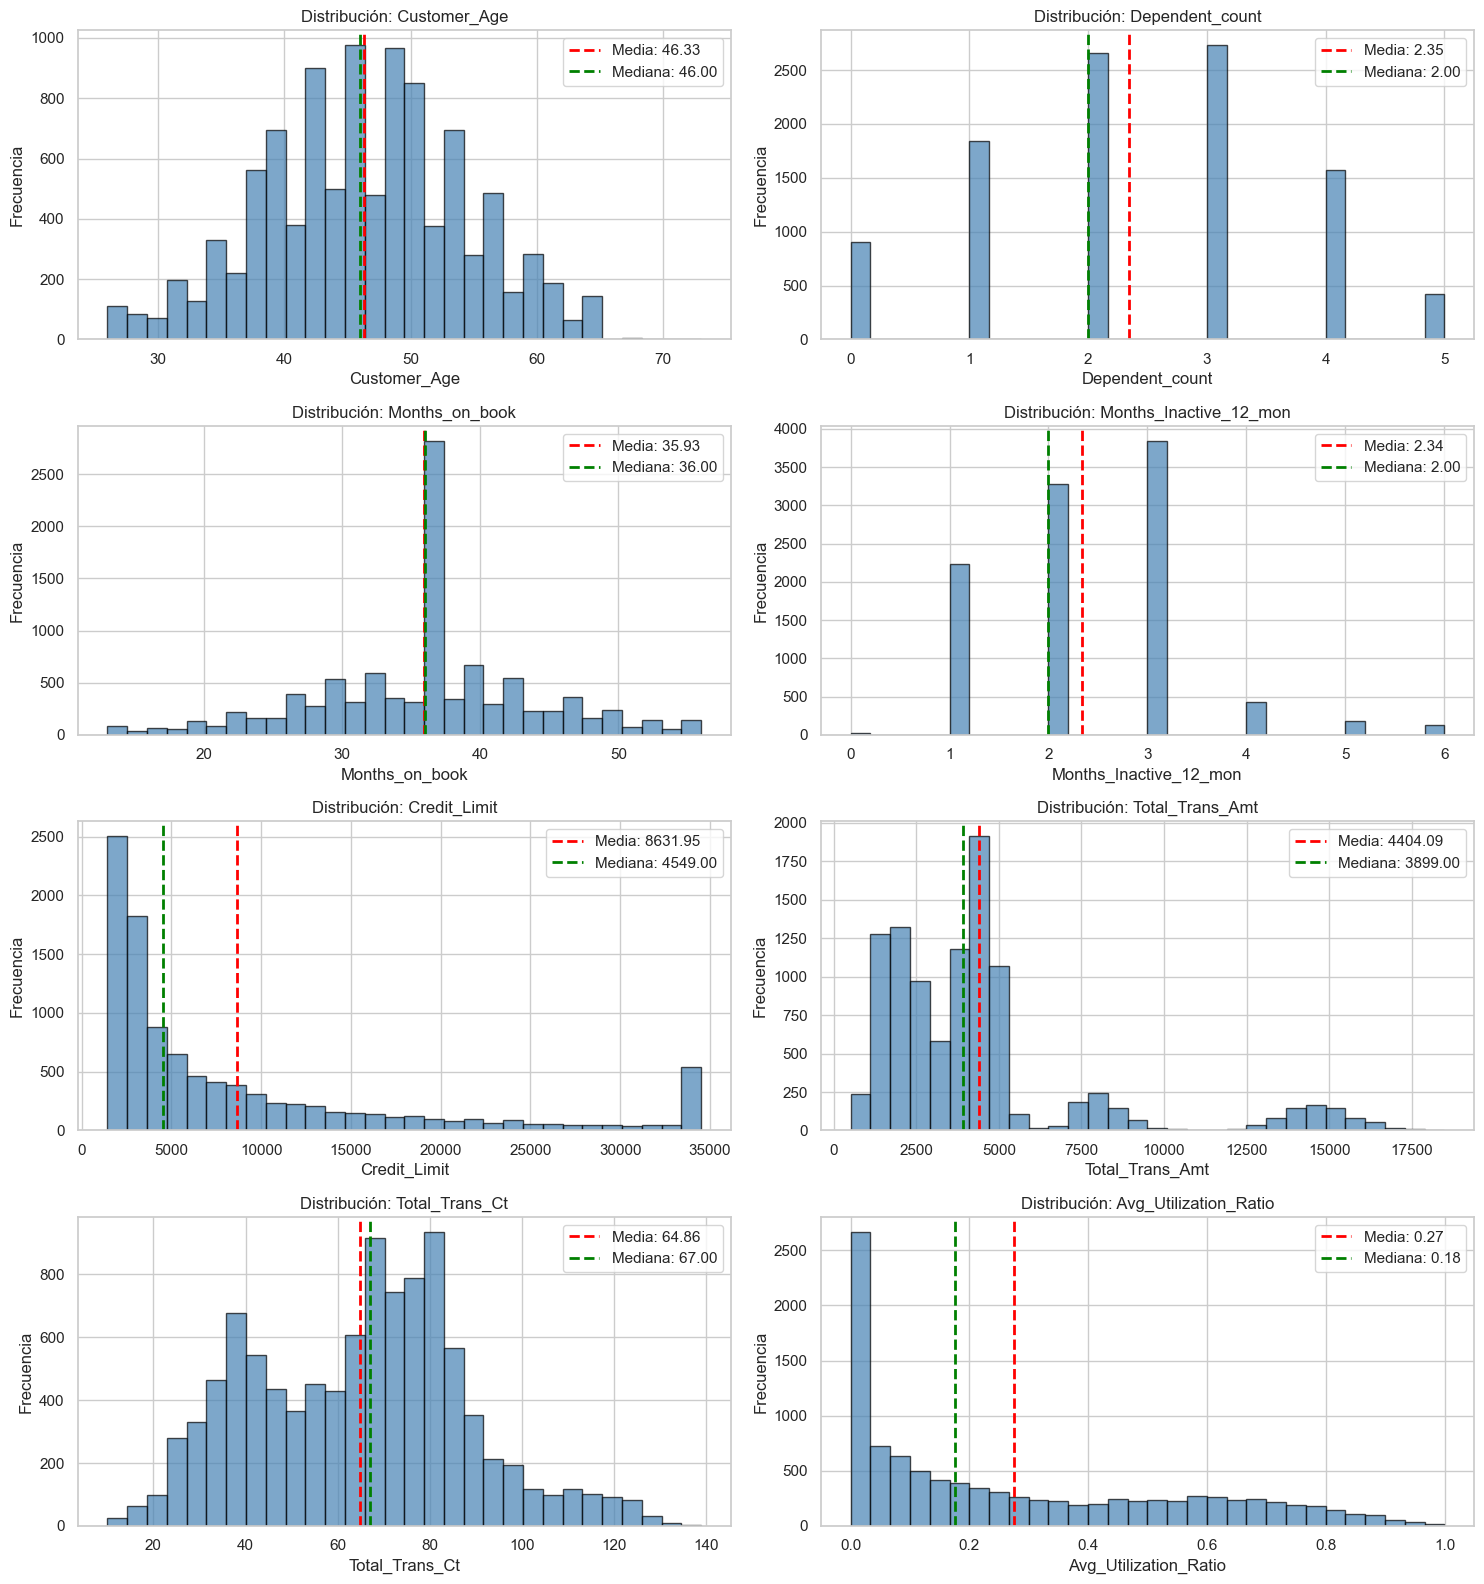

=== ESTADÍSTICAS DESCRIPTIVAS ===
       Customer_Age  Dependent_count  Months_on_book  Months_Inactive_12_mon  \
count  10127.000000     10127.000000    10127.000000            10127.000000   
mean      46.325960         2.346203       35.928409                2.341167   
std        8.016814         1.298908        7.986416                1.010622   
min       26.000000         0.000000       13.000000                0.000000   
25%       41.000000         1.000000       31.000000                2.000000   
50%       46.000000         2.000000       36.000000                2.000000   
75%       52.000000         3.000000       40.000000                3.000000   
max       73.000000         5.000000       56.000000                6.000000   

       Credit_Limit  Total_Trans_Amt  Total_Trans_Ct  Avg_Utilization_Ratio  
count  10127.000000     10127.000000    10127.000000           10127.000000  
mean    8631.953698      4404.086304       64.858695               0.274894  
std     908

In [11]:
# Visualización de Variables Numéricas

import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas en el dataset
numeric_cols = ['Customer_Age', 'Dependent_count', 'Months_on_book',
                'Months_Inactive_12_mon', 'Credit_Limit', 
                'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']

# Configuración de visualización
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

# Histogramas para cada variable numérica
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    
    # Agregar estadísticas
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df[numeric_cols].describe())

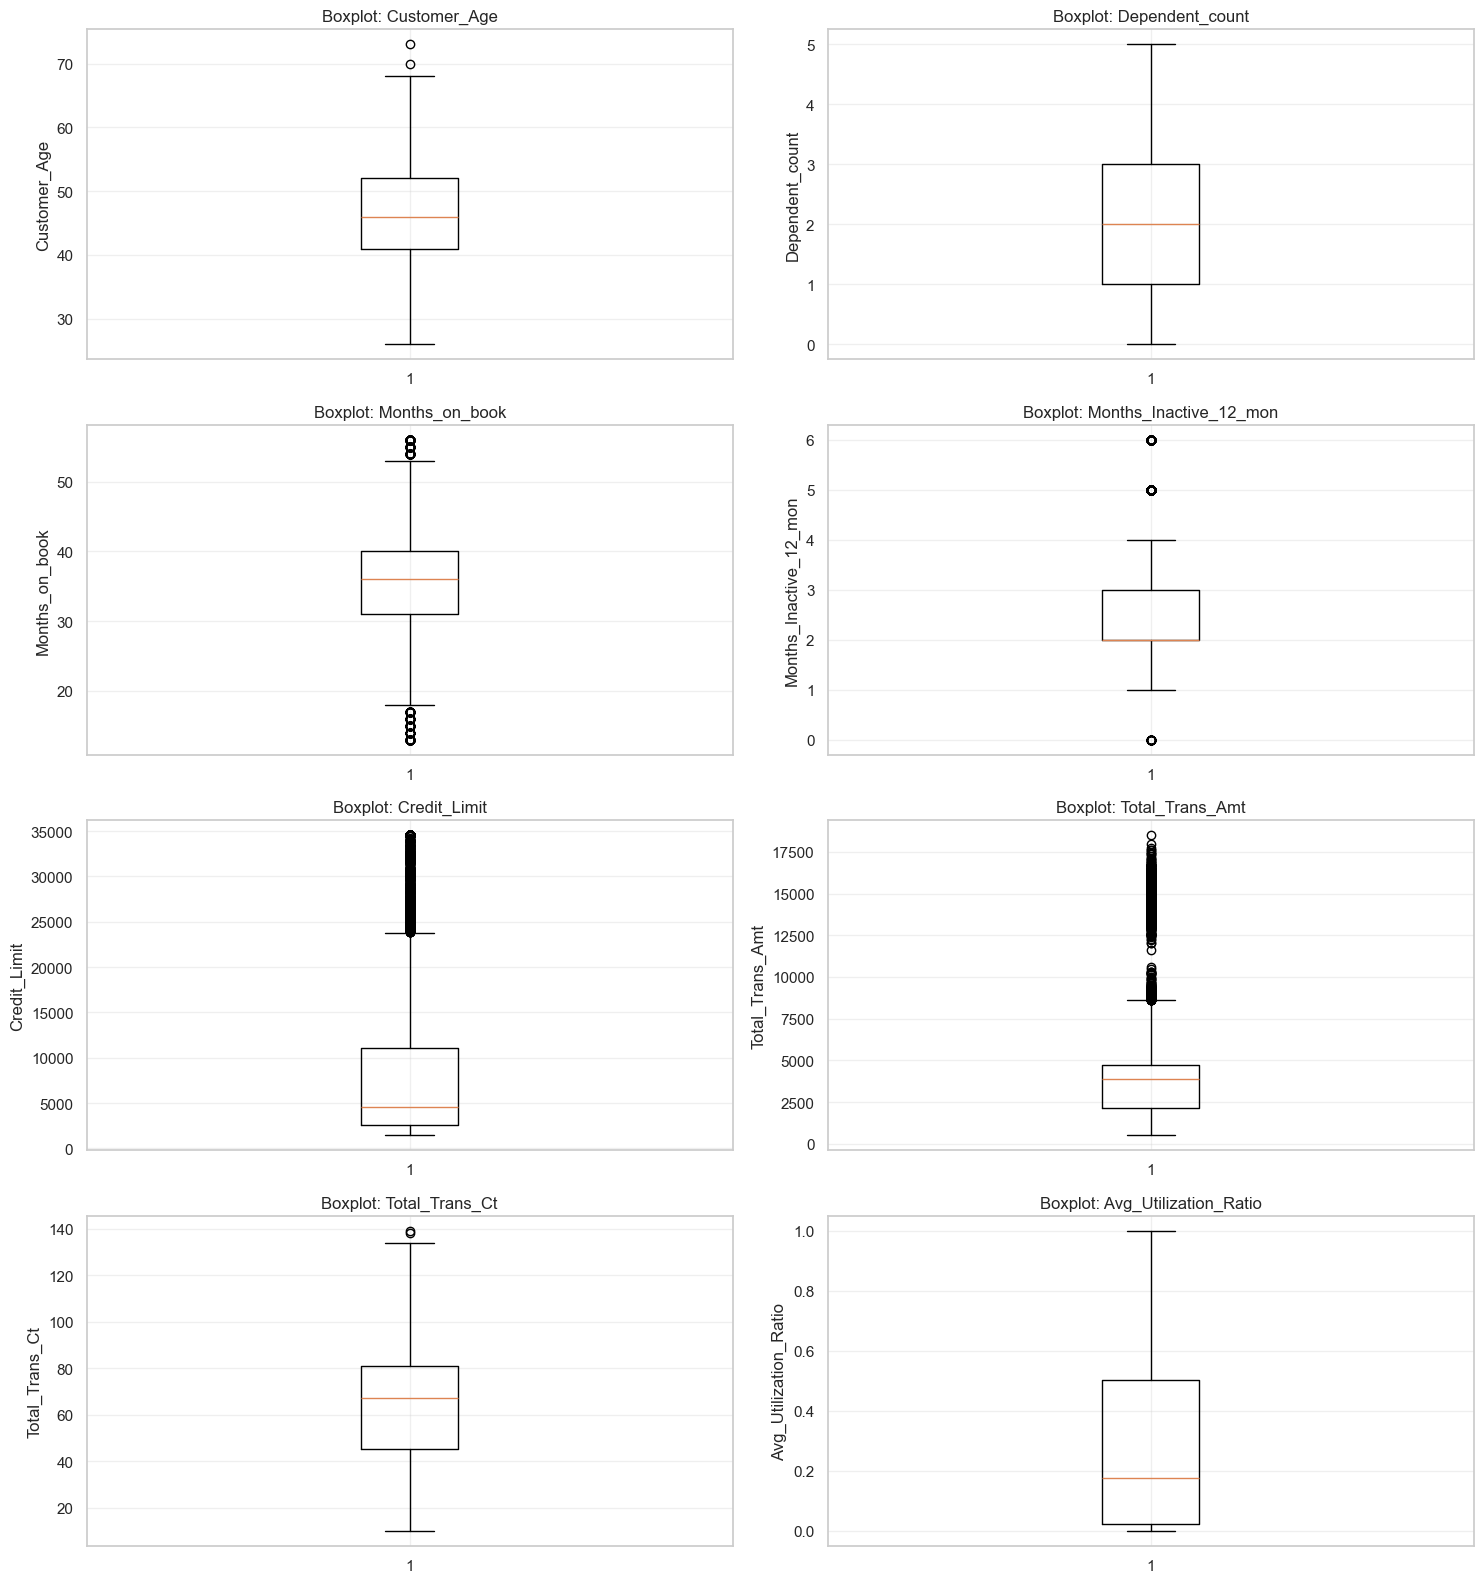

In [12]:
# Boxplots para ver outliers
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Análisis de Variables Numéricas - Decisiones de Preprocesamiento
##### Variables con distribución normal/simétrica (no requieren transformación):

- Customer_Age: Distribución normal centrada en ~46 años - bien balanceada
- Dependent_count: Distribución discreta razonable (0-5 dependientes)
- Total_Trans_Ct: Aproximadamente normal centrada en ~67 transacciones

##### Variables con outliers extremos (requieren atención):

- Credit_Limit: Outlier masivo en ~$34,000 (mediana $4,549 vs media $8,632) - hay clientes VIP con límites muy altos
- Total_Trans_Amt: Sesgada a la derecha con algunos valores muy altos
- Avg_Utilization_Ratio: Mayoría concentrada en 0.0-0.3, pero hay valores hasta 1.0

##### Variables altamente sesgadas:

- Months_on_book: Pico extremo en ~36 meses - muchos clientes tienen exactamente 3 años
- Months_Inactive_12_mon: Concentrada en 2-3 meses, distribución discreta (0-6)

In [13]:
# Transformación y Escalamiento de Variables Numéricas

import numpy as np

print("=== TRANSFORMACIÓN LOGARÍTMICA ===\n")

# Variables numéricas originales
numeric_cols = ['Customer_Age', 'Dependent_count', 'Months_on_book',
                'Months_Inactive_12_mon', 'Credit_Limit', 
                'Total_Trans_Amt', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']

# Aplicar log transform a variables sesgadas
# log1p = log(1 + x) para evitar log(0)
df['Credit_Limit_log'] = np.log1p(df['Credit_Limit'])
df['Total_Trans_Amt_log'] = np.log1p(df['Total_Trans_Amt'])

print("Variables transformadas:")
print("- Credit_Limit → Credit_Limit_log")
print("- Total_Trans_Amt → Total_Trans_Amt_log")

# Actualizar lista de variables numéricas
numeric_cols_transformed = ['Customer_Age', 'Dependent_count', 'Months_on_book',
                            'Months_Inactive_12_mon', 'Credit_Limit_log', 
                            'Total_Trans_Amt_log', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']

print("\n=== ESTADÍSTICAS DESPUÉS DE LOG TRANSFORM ===")
print(df[['Credit_Limit', 'Credit_Limit_log', 'Total_Trans_Amt', 'Total_Trans_Amt_log']].describe())

=== TRANSFORMACIÓN LOGARÍTMICA ===

Variables transformadas:
- Credit_Limit → Credit_Limit_log
- Total_Trans_Amt → Total_Trans_Amt_log

=== ESTADÍSTICAS DESPUÉS DE LOG TRANSFORM ===
       Credit_Limit  Credit_Limit_log  Total_Trans_Amt  Total_Trans_Amt_log
count  10127.000000      10127.000000     10127.000000         10127.000000
mean    8631.953698          8.603675      4404.086304             8.165164
std     9088.776650          0.933589      3397.129254             0.654246
min     1438.300000          7.271912       510.000000             6.236370
25%     2555.000000          7.846199      2155.500000             7.676242
50%     4549.000000          8.422883      3899.000000             8.268732
75%    11067.500000          9.311859      4741.000000             8.464214
max    34516.000000         10.449207     18484.000000             9.824715


In [14]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CLIENTNUM                10127 non-null  int64  
 1   Attrition_Flag           10127 non-null  int64  
 2   Customer_Age             10127 non-null  int64  
 3   Dependent_count          10127 non-null  int64  
 4   Education_Level          10127 non-null  str    
 5   Income_Category          10127 non-null  str    
 6   Months_on_book           10127 non-null  int64  
 7   Months_Inactive_12_mon   10127 non-null  int64  
 8   Credit_Limit             10127 non-null  float64
 9   Total_Trans_Amt          10127 non-null  int64  
 10  Total_Trans_Ct           10127 non-null  int64  
 11  Avg_Utilization_Ratio    10127 non-null  float64
 12  Education_Level_Encoded  10127 non-null  int64  
 13  Income_Category_Encoded  10127 non-null  int64  
 14  Card_Premium             10127 no

In [15]:
# Crear DataFrame limpio para modelado

print("=== CREACIÓN DE DATASET LIMPIO ===\n")

# 1. Seleccionar solo las columnas necesarias para modelado
features_to_keep = [
    # Variables numéricas transformadas
    'Customer_Age',
    'Dependent_count',
    'Months_on_book',
    'Months_Inactive_12_mon',
    'Credit_Limit_log',
    'Total_Trans_Amt_log',
    'Total_Trans_Ct',
    'Avg_Utilization_Ratio',
    # Variables categóricas encoded
    'Education_Level_Encoded',
    'Income_Category_Encoded',
    # One-hot encoded
    'Card_Premium'
]

# 2. Crear DataFrame limpio
df_clean = df[features_to_keep + ['Attrition_Flag']].copy()

# 3. Convertir Card_Premium de bool a int
df_clean['Card_Premium'] = df_clean['Card_Premium'].astype(int)

# 4. Verificar el dataset limpio
print("Columnas en df_clean:")
print(df_clean.columns.tolist())

print("\n=== INFO DEL DATASET LIMPIO ===")
print(df_clean.info())

print("\n=== PRIMERAS FILAS ===")
print(df_clean.head())

print("\n=== VERIFICACIÓN ===")
print(f"Shape: {df_clean.shape}")
print(f"NaN values: {df_clean.isna().sum().sum()}")
print(f"Churn distribution:")
print(df_clean['Attrition_Flag'].value_counts())

=== CREACIÓN DE DATASET LIMPIO ===

Columnas en df_clean:
['Customer_Age', 'Dependent_count', 'Months_on_book', 'Months_Inactive_12_mon', 'Credit_Limit_log', 'Total_Trans_Amt_log', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Education_Level_Encoded', 'Income_Category_Encoded', 'Card_Premium', 'Attrition_Flag']

=== INFO DEL DATASET LIMPIO ===
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_Age             10127 non-null  int64  
 1   Dependent_count          10127 non-null  int64  
 2   Months_on_book           10127 non-null  int64  
 3   Months_Inactive_12_mon   10127 non-null  int64  
 4   Credit_Limit_log         10127 non-null  float64
 5   Total_Trans_Amt_log      10127 non-null  float64
 6   Total_Trans_Ct           10127 non-null  int64  
 7   Avg_Utilization_Ratio    10127 non-null  float64
 8   Education_Le

In [16]:
df_clean.head()

,Customer_Age,Dependent_count,Months_on_book,Months_Inactive_12_mon,Credit_Limit_log,Total_Trans_Amt_log,Total_Trans_Ct,Avg_Utilization_Ratio,Education_Level_Encoded,Income_Category_Encoded,Card_Premium,Attrition_Flag
0,45,3,39,1,9.448727,7.043160,42,0.061,1,3,0,1
1,49,5,44,1,9.018817,7.163947,33,0.105,3,1,0,1
2,51,3,36,1,8.137103,7.543273,20,0.000,3,4,0,1
3,40,4,34,4,8.105911,7.066467,20,0.760,1,1,0,1
4,40,3,21,1,8.458928,6.705639,28,0.000,0,3,0,1


# Fase 01: Aplicacion modelos

## Paso 1: Train-Test Split + Escalamiento

In [17]:
# PASO 1: Train-Test Split + Escalamiento

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=== PASO 1: PREPARACIÓN DE DATOS ===\n")

# 1. Separar features (X) y target (y)
X = df_clean.drop('Attrition_Flag', axis=1)
y = df_clean['Attrition_Flag']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nDistribución del target:")
print(y.value_counts())
print(f"Churn rate: {y.mean()*100:.1f}%")

# 2. Train-Test Split (80/20 con stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n=== SPLIT COMPLETADO ===")
print(f"Train: {X_train.shape[0]} registros ({X_train.shape[0]/len(df_clean)*100:.0f}%)")
print(f"Test: {X_test.shape[0]} registros ({X_test.shape[0]/len(df_clean)*100:.0f}%)")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate: {y_test.mean()*100:.1f}%")

# 3. Escalamiento (solo para Logistic Regression)
# Variables numéricas a escalar
numeric_cols = ['Customer_Age', 'Dependent_count', 'Months_on_book',
                'Months_Inactive_12_mon', 'Credit_Limit_log', 
                'Total_Trans_Amt_log', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']

scaler = StandardScaler()

# Crear copias escaladas
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit en train, transform en ambos
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"\n=== ESCALAMIENTO COMPLETADO ===")
print("Variables escaladas:", numeric_cols)

# 4. Datasets finales
print(f"\n=== DATASETS LISTOS ===")
print(f"X_train (sin escalar): {X_train.shape} - Para árboles")
print(f"X_train_scaled: {X_train_scaled.shape} - Para Logistic Regression")
print(f"X_test (sin escalar): {X_test.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"\nNaN check:")
print(f"X_train: {X_train.isna().sum().sum()}")
print(f"X_test: {X_test.isna().sum().sum()}")

=== PASO 1: PREPARACIÓN DE DATOS ===

Features (X): (10127, 11)
Target (y): (10127,)

Distribución del target:
Attrition_Flag
1    8500
0    1627
Name: count, dtype: int64
Churn rate: 83.9%

=== SPLIT COMPLETADO ===
Train: 8101 registros (80%)
Test: 2026 registros (20%)
Train churn rate: 83.9%
Test churn rate: 84.0%

=== ESCALAMIENTO COMPLETADO ===
Variables escaladas: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Months_Inactive_12_mon', 'Credit_Limit_log', 'Total_Trans_Amt_log', 'Total_Trans_Ct', 'Avg_Utilization_Ratio']

=== DATASETS LISTOS ===
X_train (sin escalar): (8101, 11) - Para árboles
X_train_scaled: (8101, 11) - Para Logistic Regression
X_test (sin escalar): (2026, 11)
X_test_scaled: (2026, 11)

NaN check:
X_train: 0
X_test: 0


## Paso 2: Entrenar los 4 Modelos (Baseline)

In [20]:
# PASO 2: Entrenamiento de Modelos

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import time

print("=== PASO 2: ENTRENAMIENTO DE MODELOS ===\n")

# Diccionario para guardar modelos entrenados
modelos_entrenados = {}

# 1. LOGISTIC REGRESSION (usa datos escalados)
print("1. Entrenando Logistic Regression...")
start = time.time()
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)
modelos_entrenados['Logistic Regression'] = {
    'model': lr,
    'X_train': X_train_scaled,
    'X_test': X_test_scaled
}
print(f"   ✓ Completado en {time.time()-start:.2f}s\n")

# 2. DECISION TREE (usa datos sin escalar)
print("2. Entrenando Decision Tree...")
start = time.time()
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=10  # Evitar overfitting
)
dt.fit(X_train, y_train)
modelos_entrenados['Decision Tree'] = {
    'model': dt,
    'X_train': X_train,
    'X_test': X_test
}
print(f"   ✓ Completado en {time.time()-start:.2f}s\n")

# 3. RANDOM FOREST (usa datos sin escalar)
print("3. Entrenando Random Forest...")
start = time.time()
rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1  # Usar todos los cores
)
rf.fit(X_train, y_train)
modelos_entrenados['Random Forest'] = {
    'model': rf,
    'X_train': X_train,
    'X_test': X_test
}
print(f"   ✓ Completado en {time.time()-start:.2f}s\n")

# 4. XGBOOST (usa datos sin escalar)
print("4. Entrenando XGBoost...")
start = time.time()

# Calcular scale_pos_weight para desbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
modelos_entrenados['XGBoost'] = {
    'model': xgb,
    'X_train': X_train,
    'X_test': X_test
}
print(f"   ✓ Completado en {time.time()-start:.2f}s\n")

print("=== TODOS LOS MODELOS ENTRENADOS ===")
print(f"Total de modelos: {len(modelos_entrenados)}")
for nombre in modelos_entrenados.keys():
    print(f"  ✓ {nombre}")

=== PASO 2: ENTRENAMIENTO DE MODELOS ===

1. Entrenando Logistic Regression...
   ✓ Completado en 0.01s

2. Entrenando Decision Tree...
   ✓ Completado en 0.02s

3. Entrenando Random Forest...
   ✓ Completado en 0.09s

4. Entrenando XGBoost...
   ✓ Completado en 0.21s

=== TODOS LOS MODELOS ENTRENADOS ===
Total de modelos: 4
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Random Forest
  ✓ XGBoost


## Paso 3: Evaluación y Comparación de Modelos

In [22]:
# PASO 3: Evaluación de Modelos

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== PASO 3: EVALUACIÓN DE MODELOS ===\n")

# Diccionario para guardar resultados
resultados = {}

# Evaluar cada modelo
for nombre, data in modelos_entrenados.items():
    model = data['model']
    X_test_usado = data['X_test']
    
    print(f"\n{'='*60}")
    print(f"MODELO: {nombre}")
    print(f"{'='*60}")
    
    # Predicciones
    y_pred = model.predict(X_test_usado)
    y_pred_proba = model.predict_proba(X_test_usado)[:, 1]
    
    # Métricas
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Existing', 'Attrited']))
    
    print(f"\nROC-AUC Score: {roc_auc:.4f}")
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(f"TN: {cm[0,0]}, FP: {cm[0,1]}")
    print(f"FN: {cm[1,0]}, TP: {cm[1,1]}")
    
    # Guardar resultados para comparación
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    resultados[nombre] = {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# Tabla comparativa
print(f"\n{'='*60}")
print("COMPARACIÓN FINAL DE MODELOS")
print(f"{'='*60}\n")

df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados[['Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
df_resultados = df_resultados.round(4)
print(df_resultados.to_string())

# Identificar mejor modelo
print(f"\n{'='*60}")
print("MEJOR MODELO POR MÉTRICA:")
print(f"{'='*60}")
for metrica in ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    mejor = df_resultados[metrica].idxmax()
    valor = df_resultados[metrica].max()
    print(f"{metrica}: {mejor} ({valor:.4f})")

=== PASO 3: EVALUACIÓN DE MODELOS ===


MODELO: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

    Existing       0.43      0.83      0.57       325
    Attrited       0.96      0.79      0.87      1701

    accuracy                           0.80      2026
   macro avg       0.70      0.81      0.72      2026
weighted avg       0.88      0.80      0.82      2026


ROC-AUC Score: 0.8964

Confusion Matrix:
[[ 270   55]
 [ 353 1348]]
TN: 270, FP: 55
FN: 353, TP: 1348

MODELO: Decision Tree

Classification Report:
              precision    recall  f1-score   support

    Existing       0.70      0.85      0.77       325
    Attrited       0.97      0.93      0.95      1701

    accuracy                           0.92      2026
   macro avg       0.83      0.89      0.86      2026
weighted avg       0.93      0.92      0.92      2026


ROC-AUC Score: 0.9064

Confusion Matrix:
[[ 276   49]
 [ 119 1582]]
TN: 276, FP: 49
FN: 119, TP: 1582



# Conclusiones - Análisis Comparativo de Modelos (Ajustado a Contexto de Negocio)

## Contexto de Negocio: Costos Asimétricos

### 💰 Estructura de Costos
- **Falso Negativo (FN):** Cliente que hará churn pero NO detectamos
  - **Costo:** ALTO - Pierdes al cliente completamente (~$500-2000/año según Credit_Limit)
  
- **Falso Positivo (FP):** Cliente que NO hará churn pero contactamos
  - **Costo:** BAJO - Email/llamada de retención (~$5-10)

### 📊 Ratio Costo: FN es ~100-200x más caro que FP

**Implicación:** Debemos **MAXIMIZAR RECALL** (detectar todos los churners posibles)

---

## Ranking Ajustado por Costo de Negocio

### 🥇 1. Random Forest - **RECOMENDADO PARA PRODUCCIÓN**
- **Recall:** 94.7% ✅ **Detecta MÁS churners**
- **Precision:** 96.8%
- **Falsos Negativos:** 90 clientes perdidos
- **Falsos Positivos:** 54 emails/llamadas extras
- **ROC-AUC:** 0.9674

**Impacto:**
- Salva 21 clientes adicionales vs XGBoost (1,611 vs 1,588)
- Costo extra: 25 contactos innecesarios más
- **Ratio beneficio/costo:** Muy favorable

### 🥈 2. XGBoost - Alternativa balanceada
- **Recall:** 93.4% - Detecta 93 de cada 100 churners
- **Precision:** 98.2% ✅ **Menos falsos positivos**
- **Falsos Negativos:** 113 clientes perdidos
- **Falsos Positivos:** 29 contactos innecesarios
- **ROC-AUC:** 0.9778 (mejor discriminación)

**Trade-off:**
- Pierde 23 clientes más que Random Forest
- Pero envía 25 emails/llamadas menos

### 3. Decision Tree - No recomendado
- **Recall:** 93.0%
- Inferior a Random Forest en todas las métricas
- Riesgo de overfitting

### 4. Logistic Regression - Descartado
- **Recall:** 79.2% ❌ **Inaceptable**
- Pierde 353 clientes (vs 90 de Random Forest)
- **Brecha:** 263 clientes adicionales perdidos

---

## Comparación Detallada: Random Forest vs XGBoost

| Métrica | Random Forest | XGBoost | Diferencia |
|---------|--------------|---------|------------|
| **Churners Detectados** | 1,611 | 1,588 | **+23 clientes** ✅ |
| **Churners Perdidos (FN)** | 90 | 113 | **-23 clientes** ✅ |
| **Contactos Innecesarios (FP)** | 54 | 29 | +25 contactos |
| **Recall** | 94.7% | 93.4% | **+1.3%** ✅ |
| **Precision** | 96.8% | 98.2% | -1.4% |
| **ROC-AUC** | 0.9674 | 0.9778 | -0.0104 |

---

## Análisis Costo-Beneficio

### Escenario: Random Forest vs XGBoost

**Supuestos:**
- Valor promedio de cliente (CLV): $1,000/año
- Costo de contacto (email/llamada): $10
- Tasa de retención si contactamos: 30%

**Random Forest:**
- Clientes salvados: 1,611 × 30% = 483 clientes
- Ingresos retenidos: 483 × $1,000 = **$483,000**
- Costo de contactos: 1,665 × $10 = **$16,650**
- **ROI: $466,350**

**XGBoost:**
- Clientes salvados: 1,588 × 30% = 476 clientes
- Ingresos retenidos: 476 × $1,000 = **$476,000**
- Costo de contactos: 1,617 × $10 = **$16,170**
- **ROI: $459,830**

**Diferencia:** Random Forest genera **$6,520 más** de valor neto

---

## Recomendación Final Ajustada

### 🎯 **RANDOM FOREST** - Modelo recomendado para producción

**Razones:**

1. **Maximiza Recall (94.7%)** - Prioridad #1 en churn prediction
2. **Detecta 23 clientes más** que XGBoost
3. **Costo de FP es insignificante** - 25 emails extras ≈ $250 vs salvar clientes de $23,000
4. **ROI superior** - Genera más valor neto
5. **Más interpretable** - Feature importance más fácil de comunicar al negocio

### Cuándo usar XGBoost en su lugar:

- Si el costo de contacto fuera alto (>$50/contacto)
- Si la capacidad de contacto está limitada (solo X llamadas/mes)
- Si se requiere máxima precision en scoring (ROC-AUC)

---

## Impacto de Negocio - Caso Real

**Sobre 1,701 clientes que harán churn:**

| Modelo | Detectados | Perdidos | Valor Perdido* |
|--------|-----------|----------|----------------|
| **Random Forest** | 1,611 (94.7%) | 90 | **$90,000** |
| XGBoost | 1,588 (93.4%) | 113 | $113,000 |
| Logistic Regression | 1,348 (79.2%) | 353 | $353,000 |

*Asumiendo CLV promedio de $1,000

**Conclusión:** Random Forest reduce pérdidas en $23,000 vs XGBoost y $263,000 vs Logistic Regression

---

## Decisión Final

✅ **Implementar RANDOM FOREST en producción**

**Criterio de decisión:** En problemas de churn con costos asimétricos (FN >> FP), **maximizar Recall es más importante que maximizar Precision**.

Random Forest ofrece el mejor balance para el contexto de negocio donde contactar clientes tiene bajo costo pero perder clientes es muy costoso.